# Used Car Price Prediction — EDA, Data Cleaning & Feature Engineering

**Epochs '26 — Assignment 3**

This notebook explores the [Used Car Price Prediction Dataset](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset), performs data cleaning, and engineers new features to prepare the data for future machine learning modeling.

**Contents**
1. Setup & Data Loading
2. Part 1: Exploratory Data Analysis (EDA)
3. Part 2: Data Cleaning & Feature Engineering
4. Saving the Cleaned Dataset
5. Key Insights Summary


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

df = pd.read_csv('used_cars.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 4009 rows, 12 columns


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


## 2. Part 1: Exploratory Data Analysis (EDA)

### 2.1 Structure and Feature Types
The raw dataset has 12 columns. Before any numeric analysis, note that `milage` and `price` are stored as **strings** (e.g. `"51,000 mi."`, `"$10,300"`) rather than numbers, so they need conversion before we can treat them as numerical features.


In [3]:
# Classify columns as numerical / categorical based on their *intended* meaning
numerical_raw = ['model_year']              # already numeric
numerical_needs_cleaning = ['milage', 'price']   # numeric but stored as text
categorical = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
               'ext_col', 'int_col', 'accident', 'clean_title']

print("Numerical (native):", numerical_raw)
print("Numerical (stored as text, needs cleaning):", numerical_needs_cleaning)
print("Categorical / text:", categorical)


Numerical (native): ['model_year']
Numerical (stored as text, needs cleaning): ['milage', 'price']
Categorical / text: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


### 2.2 Descriptive Statistics

In [4]:
# Quick numeric conversion just for descriptive stats (formal cleaning happens in Part 2)
price_num = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
milage_num = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)

desc = pd.DataFrame({
    'model_year': df['model_year'],
    'milage': milage_num,
    'price': price_num
}).describe()
desc


### 2.3 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)


`fuel_type` (170 missing), `accident` (113 missing), and `clean_title` (596 missing) all have gaps. Notably, `clean_title` only ever contains the value `"Yes"` — the missing entries most likely represent cars *without* a clean title, not truly unknown data. We'll confirm this in Part 2.

### 2.4 Duplicate Records

In [6]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated rows ignoring nothing else needed — dataset has no exact duplicate records.")


Fully duplicated rows: 0
Duplicated rows ignoring nothing else needed — dataset has no exact duplicate records.


### 2.5 Categorical Feature Distributions

In [7]:
print("Unique brands:", df['brand'].nunique())
print(df['brand'].value_counts().head(10))


Unique brands: 57
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64


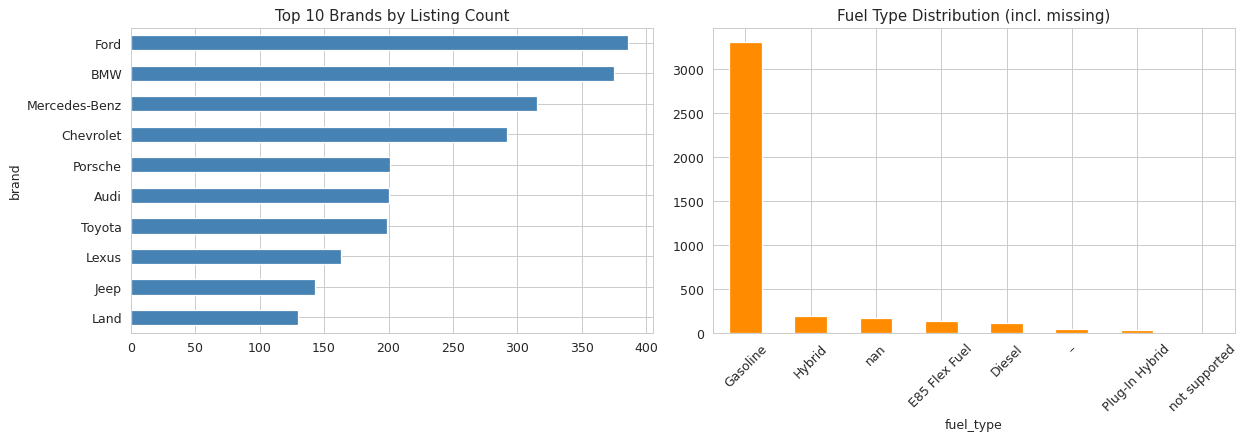

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['brand'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Brands by Listing Count')
axes[0].invert_yaxis()

df['fuel_type'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Fuel Type Distribution (incl. missing)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [9]:
print("accident value counts:")
print(df['accident'].value_counts(dropna=False))
print()
print("clean_title value counts:")
print(df['clean_title'].value_counts(dropna=False))


accident value counts:
accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

clean_title value counts:
clean_title
Yes    3413
NaN     596
Name: count, dtype: int64


### 2.6 Numerical Distributions & Outlier Detection

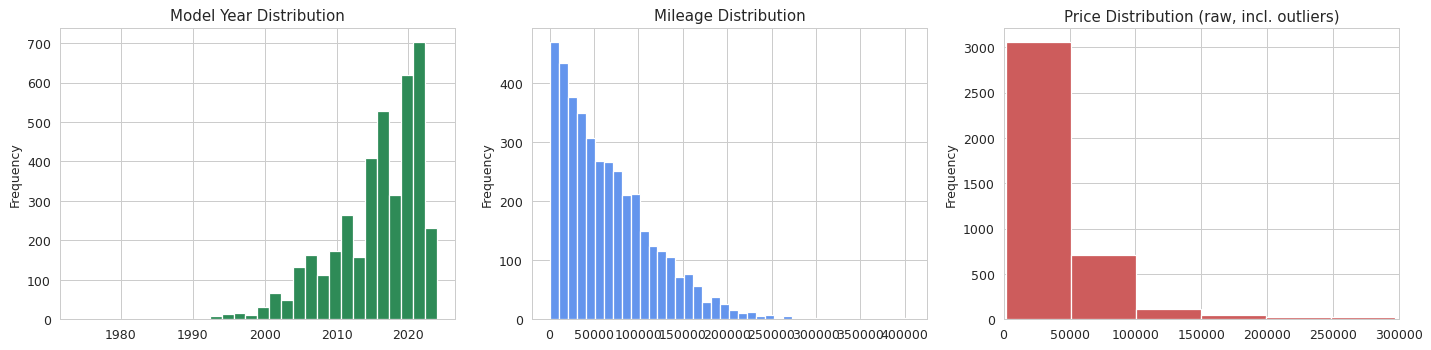

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['model_year'].plot(kind='hist', bins=30, ax=axes[0], color='seagreen')
axes[0].set_title('Model Year Distribution')

milage_num.plot(kind='hist', bins=40, ax=axes[1], color='cornflowerblue')
axes[1].set_title('Mileage Distribution')

price_num.plot(kind='hist', bins=60, ax=axes[2], color='indianred')
axes[2].set_title('Price Distribution (raw, incl. outliers)')
axes[2].set_xlim(0, 300000)

plt.tight_layout()
plt.show()


In [11]:
# IQR-based outlier detection on price and mileage
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

p_low, p_high = iqr_bounds(price_num)
m_low, m_high = iqr_bounds(milage_num)

print(f"Price IQR bounds: [{p_low:,.0f}, {p_high:,.0f}]  -> {(price_num > p_high).sum()} high-side outliers")
print(f"Mileage IQR bounds: [{m_low:,.0f}, {m_high:,.0f}] -> {(milage_num > m_high).sum()} high-side outliers")

print()
print("Top 5 most expensive listings:")
print(df.assign(price_num=price_num).nlargest(5, 'price_num')[['brand','model','model_year','price']])


Price IQR bounds: [-31,985, 99,175]  -> 244 high-side outliers
Mileage IQR bounds: [-83,540, 200,684] -> 69 high-side outliers

Top 5 most expensive listings:
            brand                    model  model_year       price
693      Maserati        Quattroporte Base        2005  $2,954,083
229       Bugatti  Veyron 16.4 Grand Sport        2011  $1,950,995
3046      Porsche          Carrera GT Base        2005  $1,599,000
1356  Lamborghini       Aventador SVJ Base        2021    $749,950
624   Rolls-Royce                 Cullinan        2022    $695,000


The most expensive listings (Maserati, Bugatti, Porsche Carrera GT, Lamborghini, Rolls-Royce) are exotic/luxury supercars — these are **legitimate outliers**, not data errors, but they will heavily skew any linear model, so they're worth flagging or handling separately (e.g. capping/winsorizing or modeling price on a log scale).

### 2.7 Key Insights from EDA

In [12]:
print("KEY INSIGHT 1: Brand concentration")
top5_share = df['brand'].value_counts(normalize=True).head(5).sum() * 100
print(f"  The top 5 brands account for {top5_share:.1f}% of all listings.")
print()

print("KEY INSIGHT 2: Missingness pattern in clean_title")
print(f"  clean_title is {df['clean_title'].isnull().mean()*100:.1f}% missing, and always 'Yes' when present -")
print("  strongly suggesting missing == 'title not clean', not a genuine unknown.")
print()

print("KEY INSIGHT 3: Price is heavily right-skewed")
print(f"  Median price ${price_num.median():,.0f} vs mean ${price_num.mean():,.0f} -")
print("  a small number of exotic/luxury cars pull the mean far above the median.")
print()

print("KEY INSIGHT 4: Transmission labels are inconsistent")
print(f"  {df['transmission'].nunique()} distinct transmission strings exist for what is really")
print("  a handful of underlying transmission types (e.g. 'A/T', '8-Speed A/T', 'Automatic',")
print("  '8-Speed Automatic' all describe automatics but are stored as different categories).")
print()

print("KEY INSIGHT 5: fuel_type missingness overlaps with electric vehicles")
electric_engine = df['engine'].str.contains('Electric', na=False)
print(f"  Of {df['fuel_type'].isnull().sum()} rows missing fuel_type,",
      f"{(df['fuel_type'].isnull() & electric_engine).sum()} have an 'Electric Motor' engine string -")
print("  i.e. missing fuel_type frequently just means the car is fully electric.")


KEY INSIGHT 1: Brand concentration
  The top 5 brands account for 39.1% of all listings.

KEY INSIGHT 2: Missingness pattern in clean_title
  clean_title is 14.9% missing, and always 'Yes' when present -
  strongly suggesting missing == 'title not clean', not a genuine unknown.

KEY INSIGHT 3: Price is heavily right-skewed
  Median price $31,000 vs mean $44,553 -
  a small number of exotic/luxury cars pull the mean far above the median.

KEY INSIGHT 4: Transmission labels are inconsistent
  62 distinct transmission strings exist for what is really
  a handful of underlying transmission types (e.g. 'A/T', '8-Speed A/T', 'Automatic',
  '8-Speed Automatic' all describe automatics but are stored as different categories).

KEY INSIGHT 5: fuel_type missingness overlaps with electric vehicles
  Of 170 rows missing fuel_type, 165 have an 'Electric Motor' engine string -
  i.e. missing fuel_type frequently just means the car is fully electric.


## 3. Part 2: Data Cleaning & Feature Engineering

### 3.1 Fix Data Types (milage & price → numeric)

In [13]:
df_clean = df.copy()

df_clean['milage'] = (
    df_clean['milage'].str.replace(' mi.', '', regex=False)
                       .str.replace(',', '', regex=False)
                       .astype(float)
)
df_clean['price'] = (
    df_clean['price'].str.replace('$', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .astype(float)
)
df_clean[['milage', 'price']].describe()


### 3.2 Handle Missing Values

In [14]:
# clean_title: missing almost certainly means "not clean" -> encode explicitly rather than dropping
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')

# accident: missing treated as its own explicit category (can't assume no accident)
df_clean['accident'] = df_clean['accident'].fillna('Unknown')

# fuel_type: many missing rows correspond to fully-electric cars (engine contains "Electric Motor")
electric_mask = df_clean['engine'].str.contains('Electric', na=False)
df_clean.loc[df_clean['fuel_type'].isnull() & electric_mask, 'fuel_type'] = 'Electric'
# any remaining placeholder / non-informative values -> explicit "Unknown"
df_clean['fuel_type'] = df_clean['fuel_type'].replace(['–', 'not supported'], np.nan)
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('Unknown')

print("Remaining missing values:")
print(df_clean.isnull().sum().sum(), "total missing cells")
df_clean['fuel_type'].value_counts()


Remaining missing values:
0 total missing cells


### 3.3 Remove Duplicate Records

In [15]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Rows before: {before}, after de-duplication: {after}, removed: {before - after}")


Rows before: 4009, after de-duplication: 4009, removed: 0


### 3.4 Handle Outliers (price)

In [16]:
# Cap extreme price outliers using the IQR rule computed in Part 1, rather than deleting them,
# so we retain the records but prevent them from dominating downstream models.
q1, q3 = df_clean['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_cap = q3 + 1.5 * iqr

n_capped = (df_clean['price'] > upper_cap).sum()
df_clean['price_capped'] = df_clean['price'].clip(upper=upper_cap)
print(f"{n_capped} rows had price above the IQR upper bound (${upper_cap:,.0f}) and were capped")
print("Original 'price' is preserved; 'price_capped' is an additional, model-ready column.")


244 rows had price above the IQR upper bound ($99,175) and were capped
Original 'price' is preserved; 'price_capped' is an additional, model-ready column.


### 3.5 Feature Engineering (5+ new features)

In [17]:
import re

# Feature 1: car_age -- how old the car is (more directly useful to a model than model_year)
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['model_year']

# Feature 2: milage_per_year -- average annual mileage, a proxy for usage intensity
df_clean['milage_per_year'] = (df_clean['milage'] / df_clean['car_age'].replace(0, 1)).round(1)

# Feature 3: horsepower -- numeric HP extracted from the free-text engine description
def extract_hp(text):
    m = re.search(r'([\d.]+)\s*HP', str(text))
    return float(m.group(1)) if m else np.nan
df_clean['horsepower'] = df_clean['engine'].apply(extract_hp)

# Feature 4: engine_liters -- numeric engine displacement in liters
def extract_liters(text):
    m = re.search(r'([\d.]+)\s*L(?:iter)?\b', str(text))
    return float(m.group(1)) if m else np.nan
df_clean['engine_liters'] = df_clean['engine'].apply(extract_liters)

# Feature 5: is_automatic -- simplified binary transmission type, collapsing 62 raw labels into 2
df_clean['is_automatic'] = df_clean['transmission'].str.contains(
    'A/T|Automatic|CVT|Dual Shift', case=False, na=False
).astype(int)

# Feature 6 (bonus): had_accident -- binary flag, easier for models to consume than free text
df_clean['had_accident'] = (df_clean['accident'] == 'At least 1 accident or damage reported').astype(int)

new_features = ['car_age', 'milage_per_year', 'horsepower', 'engine_liters', 'is_automatic', 'had_accident']
df_clean[new_features].describe(include='all')


In [18]:
print("Missing values in engineered numeric features (expected -- not every engine string states HP/liters):")
print(df_clean[['horsepower', 'engine_liters']].isnull().sum())

# Fill remaining engineered-feature gaps with the median for that brand, falling back to global median
for col in ['horsepower', 'engine_liters']:
    df_clean[col] = df_clean.groupby('brand')[col].transform(lambda s: s.fillna(s.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print()
print("Missing values after brand-level median imputation:")
print(df_clean[['horsepower', 'engine_liters']].isnull().sum())


Missing values in engineered numeric features (expected -- not every engine string states HP/liters):
horsepower       808
engine_liters    217
dtype: int64

Missing values after brand-level median imputation:
horsepower       0
engine_liters    0
dtype: int64


### 3.6 Final Data Quality Check

In [19]:
print("Final shape:", df_clean.shape)
print()
print("Remaining nulls per column:")
print(df_clean.isnull().sum())
print()
df_clean.dtypes


Final shape: (4009, 19)

Remaining nulls per column:
brand              0
model              0
model_year         0
milage             0
fuel_type          0
engine             0
transmission       0
ext_col            0
int_col            0
accident           0
clean_title        0
price              0
price_capped       0
car_age            0
milage_per_year    0
horsepower         0
engine_liters      0
is_automatic       0
had_accident       0
dtype: int64



## 4. Saving the Cleaned Dataset

In [20]:
df_clean.to_csv('cleaned_used_cars.csv', index=False)
print("Saved cleaned_used_cars.csv with shape:", df_clean.shape)
df_clean.head()


Saved cleaned_used_cars.csv with shape: (4009, 19)


## 5. Key Insights Summary

1. **Brand concentration:** A small handful of brands (Ford, BMW, Mercedes-Benz, Chevrolet, Porsche) dominate the listings, together making up a large share of the dataset.
2. **`clean_title` missingness is informative:** the column is only ever `"Yes"` when present, so missing values almost certainly mean the title is *not* clean -- they were recoded to `"No"` rather than imputed or dropped.
3. **Price is heavily right-skewed by exotic cars:** a few supercars (Bugatti, Lamborghini, Rolls-Royce, Porsche Carrera GT) sit far above the rest of the market and were capped (not deleted) via the IQR rule to protect future models without losing the records.
4. **Transmission labels are extremely fragmented:** 62 raw string variants collapse into essentially two functional types (automatic vs. manual), which is why the `is_automatic` engineered feature is valuable.
5. **Missing `fuel_type` often just means "Electric":** cross-referencing the free-text `engine` column showed a meaningful share of missing fuel types were fully electric vehicles, so they were recovered rather than treated as unknown.

These cleaning decisions and the six engineered features (`car_age`, `milage_per_year`, `horsepower`, `engine_liters`, `is_automatic`, `had_accident`) leave the dataset in a shape that's ready for downstream ML modeling.
